<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_14_clustering.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
# run this first
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=25083ce49fa4cefec4e5a730556a932efffeb4820c10425802f5089459ae2954
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


# BYU CS 473 — Comparing HAC, K-Means, and K-Medoids  

In this assignment, you will learn the similarities and differences between **Hierarchical Agglomerative Clustering (HAC)** with different linkage strategies and **partitioning methods** such as k-means and k-medoids.  

We will emphasize the tradeoffs between linkage strategies in HAC and why **k-medoids** can sometimes be more robust than k-means.  

---

## Learning Goals
- Understand how **HAC** works with different linkage methods:  
  - Single Link (nearest-neighbor / minimum distance)  
  - Complete Link (furthest-neighbor / maximum distance)  
  - Average Link (mean distance)  
- Compare **HAC** with **k-means** clustering.  
- Understand why **k-medoids** is a robust alternative to k-means.  
- Visualize clustering results to see strengths and weaknesses.  

## Part 1 — Hierarchical Agglomerative Clustering (HAC)  

Hierarchical Agglomerative Clustering starts with each data point in its own cluster and **merges clusters step by step** until only one cluster remains.  

The choice of **linkage** determines how distances between clusters are measured:  
- **Single Link**: distance between the two *closest* points (can cause "chaining")  
- **Complete Link**: distance between the two *furthest* points (tends to form compact clusters)  
- **Average Link**: average distance between all points across clusters (balances chaining and compactness)  

### Task:
1. Generate a synthetic 2D dataset (e.g., blobs or moons).  
2. Apply HAC with each linkage method.  
3. Visualize dendrograms and final clusters.  


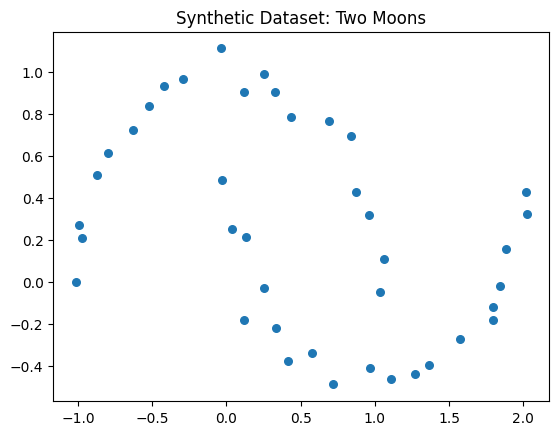

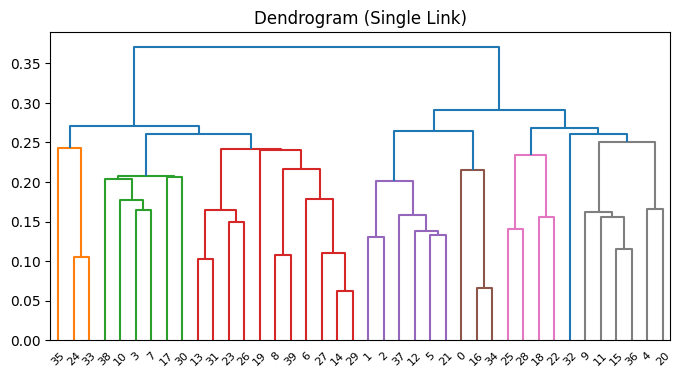

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# Create synthetic dataset
X, y_true = make_moons(n_samples=40, noise=0.05, random_state=42)

# Plot dataset
plt.scatter(X[:,0], X[:,1], s=30)
plt.title("Synthetic Dataset: Two Moons")
plt.show()

# Dendrogram
plt.figure(figsize=(8,4))
dendrogram = sch.dendrogram(sch.linkage(X, method='single'))
plt.title("Dendrogram (Single Link)")
plt.show()


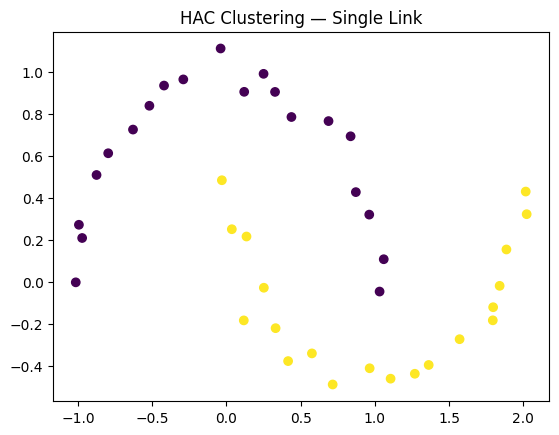

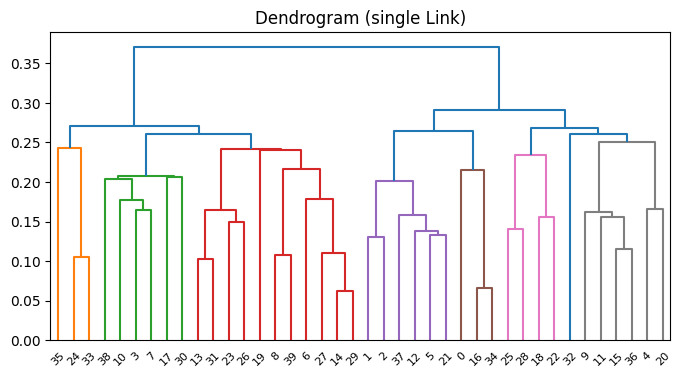

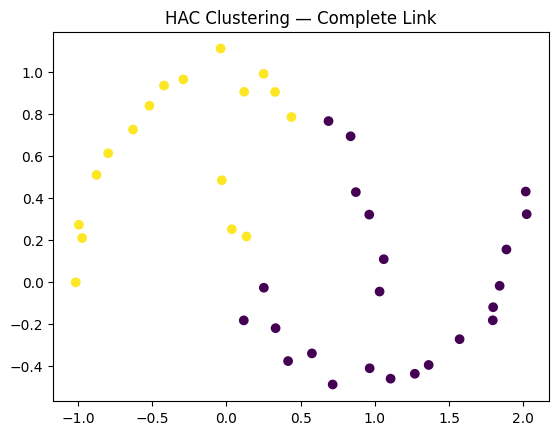

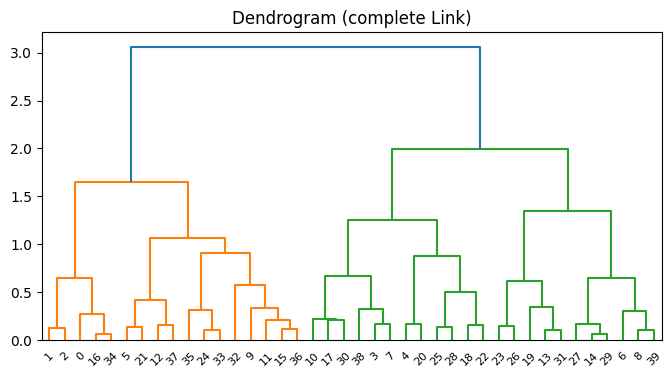

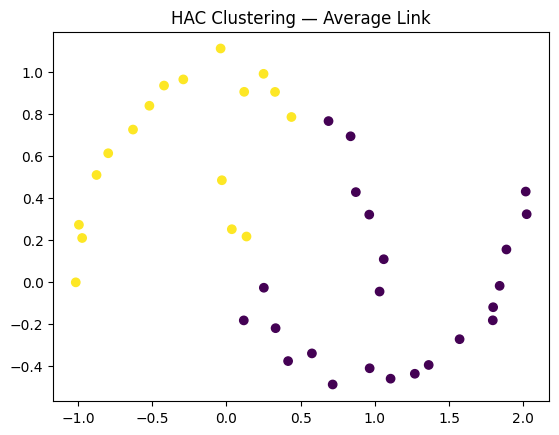

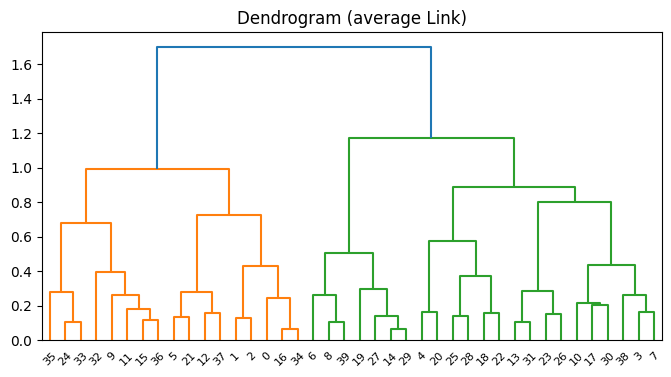

In [9]:
# HAC with different linkages
for method in ['single','complete','average']:
    hac = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = hac.fit_predict(X)

    plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis")
    plt.title(f"HAC Clustering — {method.title()} Link")
    plt.show()
    # Dendrogram
    plt.figure(figsize=(8,4))
    dendrogram = sch.dendrogram(sch.linkage(X, method=method))
    plt.title(f"Dendrogram ({method} Link)")
    plt.show()



## Part 2 — K-Means Clustering  

K-means clustering partitions data into **k clusters** by:  
1. Randomly initializing k centroids  
2. Assigning each point to the nearest centroid  
3. Updating centroids as the **mean** of assigned points  
4. Repeating until convergence  

### Task:
1. Apply k-means to the same dataset.  
2. Compare results to HAC.  

**Question:** What happens to k-means on non-spherical data (like moons)?  


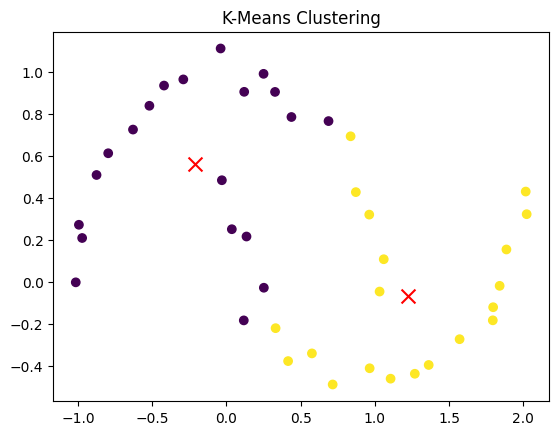

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels_kmeans, cmap="viridis")
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c="red", marker="x", s=100)
plt.title("K-Means Clustering")
plt.show()


Interestingly enough, the classes are almost exactly the same as the average link method of HAC. The points that are close in euclidean distances (but do not respec tthe topology of the data) end up in the closest centroid, so the moons actually end up mixing together precisely where the average linkage method mixed. It makes sense; these are two related methods.



## Part 3 — K-Medoids (Partitioning Around Medoids, PAM) on Moon Dataset

K-medoids is similar to k-means, **but instead of using the mean**, it chooses actual **data points (medoids)** as cluster centers.  

This makes k-medoids more **robust to outliers** and suitable for arbitrary distance metrics (not just Euclidean).  

### Task:
1. Apply k-medoids (PAM algorithm) to the dataset.  
2. Compare results to k-means.  


Cluster assignments: [[0, 1, 2, 5, 9, 10, 11, 12, 15, 16, 17, 21, 24, 30, 32, 33, 34, 35, 36, 37], [3, 4, 6, 7, 8, 13, 14, 18, 19, 20, 22, 23, 25, 26, 27, 28, 29, 31, 38, 39]]
Medoid indices: [35, 22]


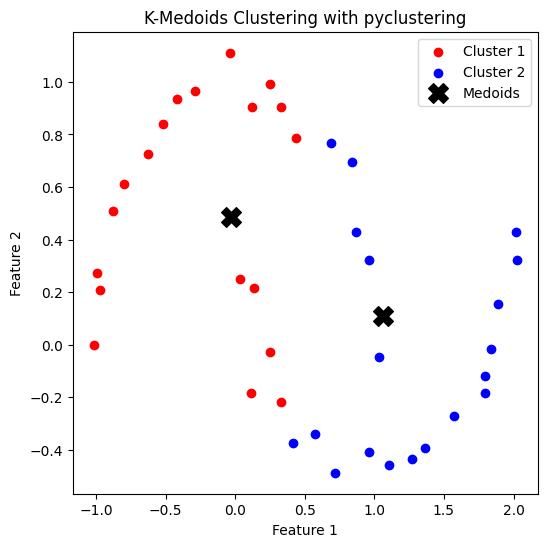

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import calculate_distance_matrix



# Choose initial medoids (indices of points in X)
initial_medoids = [0, 25]

# Run K-Medoids
kmedoids_instance = kmedoids(X.tolist(), initial_medoids, data_type='points')
kmedoids_instance.process()

clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

print("Cluster assignments:", clusters)
print("Medoid indices:", medoids)

# --- Visualization ---
colors = ['red', 'blue', 'green', 'orange', 'purple']

plt.figure(figsize=(6, 6))
for cluster_idx, cluster in enumerate(clusters):
    points = np.array([X[i] for i in cluster])
    plt.scatter(points[:, 0], points[:, 1],
                c=colors[cluster_idx % len(colors)],
                label=f"Cluster {cluster_idx+1}")

# Plot medoids
medoid_points = np.array([X[i] for i in medoids])
plt.scatter(medoid_points[:, 0], medoid_points[:, 1],
            c='black', marker='X', s=200, label="Medoids")

plt.title("K-Medoids Clustering with pyclustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


We see some pretty similar patterns as k-means, as in that on spherical data, we end up with medoids on the opposite class's tail that is supposed to be describing the class that is not the class that the mediod is a part of the tail of.

## Part 4 — Reflection  

1. Which HAC linkage method worked best for the moons dataset? Why?  
2. How does the dendrogram help us decide the number of clusters?  
3. What was the main weakness of k-means in this example?  
4. Why is k-medoids more robust than k-means?  
5. In practice, when would you prefer HAC vs. k-means vs. k-medoids?  


1) The single linkage method was by far the best. This is because with moons and really any typew of data with a specific nonlinear unbroken topology, the closest neighbors are actually members of the same class. Other methods mess this up because average and complete link allow close, but wrong class points to influence the means/centroids (i.e. they optimize for global cluster shape to have small diameter rather than local shape with distances between).

2) Dendrogram lets us see the relative distances between clusters. We know that we have reached a good amount of clusters because there are long verticle lines before a horizontal merge, which signifies great distance between clusters.

3) K-means is built off of the first moment of a dataset. Without mahalanobis distance/some other kind of nonlinear correction, it will misclassify clusters because they aren't linear. It can't respect nonlinear topolographic patterns, especially convex ones.

4) k-medoids is generally more robust than K means because medoids defines distance with L1 norm but means uses L2 squared distances. This means that outliers really affect k means but not so much to k medoids.

Additionally, k medoids finds the argmin point where the least distances between it and every other point in the cluster are. That's what we need here.

5)

When our data is easily linearly separable, k-means will do well. K-means is also very scalable.

When our data is formed from many clusters and we don't know how many, HAC is a good idea; HAC also lets us kind of act like an SVM becuase we can change our margins via complete/average/single linkage. HAC is also deterministic.

When our data is structured so that points in any cluster don't obey gaussian distribution, k-medoids is good becuase it finds the best point to define distance off of (which is not the mean). It also gives us non-euclidean distance and adapts to outliers better.